# SHAP Analysis

This notebook applies SHAP (Shapley Additive Explanations) to interpret the predictions of the machine learning model.

SHAP provides:
- Global explanations (feature importance)
- Local explanations (individual predictions)

This helps improve transparency and supports explainable AI in fraud detection.

In [2]:
#Imports
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import os

In [3]:
#Load model
X_test = pd.read_csv("../data/processed/X_test.csv")

model = joblib.load("../models/logistic_model.pkl")

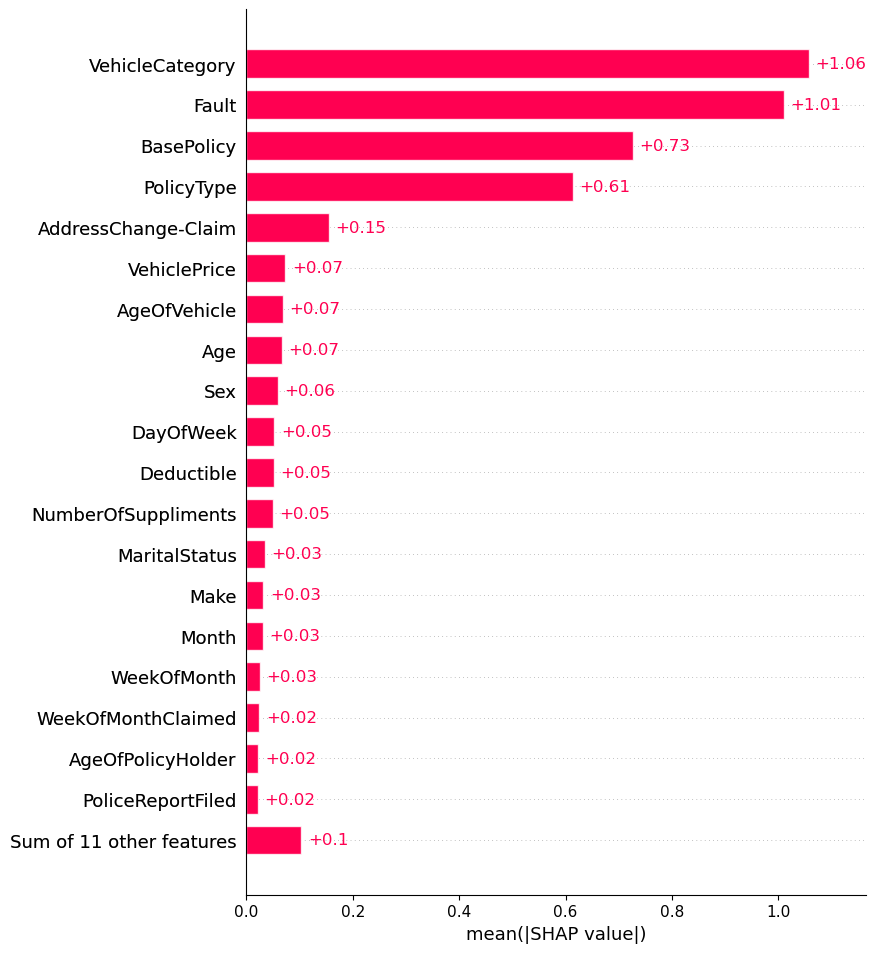

In [4]:
#Create SHAP explainer
explainer = shap.Explainer(model, X_test)

#Calculate SHAP values
shap_values = explainer(X_test)

#SHAP bar plot 
shap.plots.bar(shap_values, max_display=20, show=False)

#Save
plt.savefig("../reports/figures/shap_global_importance.png", bbox_inches='tight')
plt.show()
plt.close()

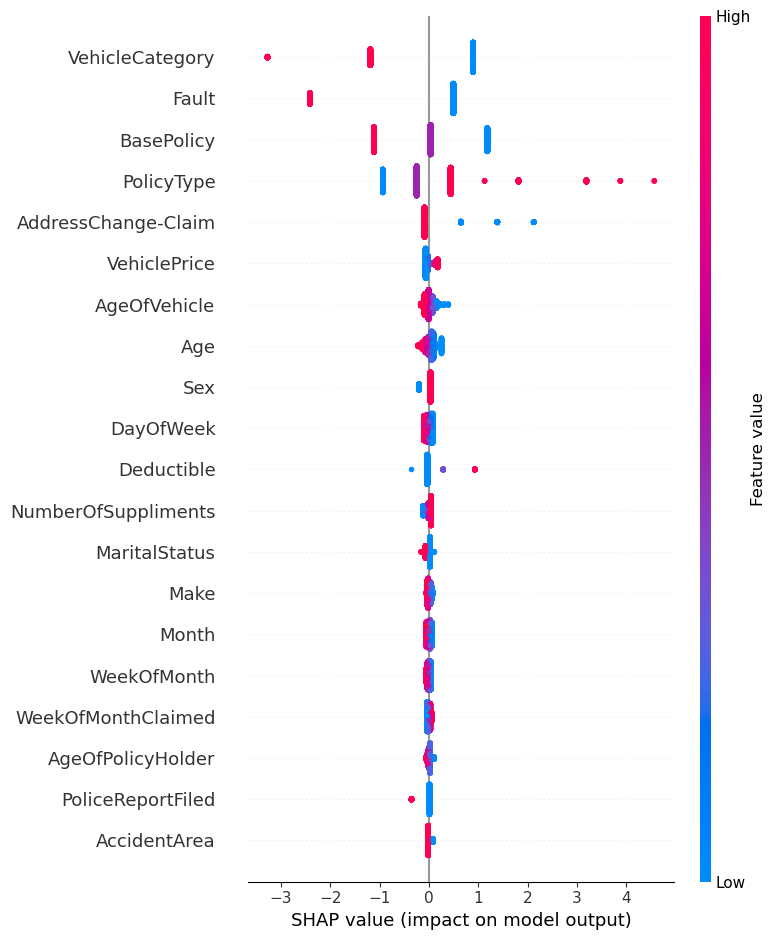

In [5]:
#SHAP summary plot
shap.summary_plot(shap_values, X_test, show=False)

#Save
plt.savefig("../reports/figures/shap_summary_plot.png", bbox_inches='tight')
plt.show()
plt.close()


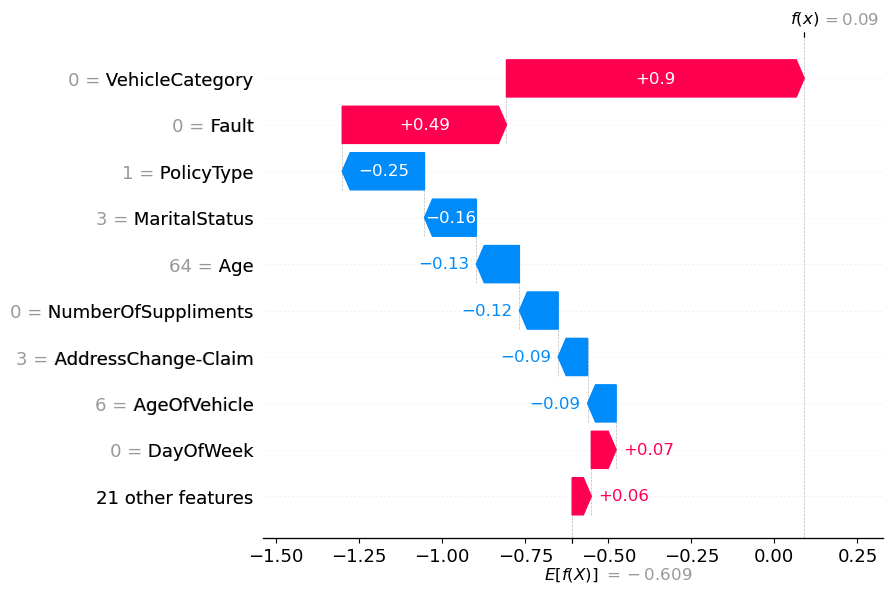

In [23]:
#Explain one prediction - waterfall

i = 99  #Change this for a differnet individual explantion 

fig = plt.figure()
shap.plots.waterfall(shap_values[i], show=False)

#Save with individual name
plt.savefig(f"../reports/figures/shap_local_explanation_{i}.png", bbox_inches='tight')

plt.show()
plt.close()